In [2]:
from google.colab import files
uploaded = files.upload()

Saving exercise.csv to exercise.csv


In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv('exercise.csv')
print(df.head())
print(df.dtypes)

   slno  id     diet  pulse    time  kind
0     0   1  low fat     85   1 min  rest
1     1   1  low fat     85  15 min  rest
2     2   1  low fat     88  30 min  rest
3     3   2  low fat     90   1 min  rest
4     4   2  low fat     92  15 min  rest
slno      int64
id        int64
diet     object
pulse     int64
time     object
kind     object
dtype: object


In [6]:
print("mean:\n", df['pulse'].mean())
print("variance:\n", df['pulse'].var())
print("std dev:\n", df['pulse'].std())

mean:
 99.7
variance:
 220.7741573033708
std dev:
 14.858470893849434


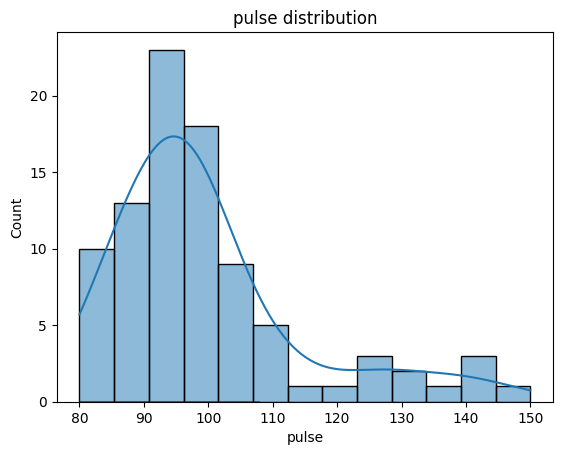

In [8]:
import matplotlib.pyplot as plt
plt.hist(df['pulse'], bins = 10, density = True)

import seaborn as sns
sns.histplot(df['pulse'], kde = True)
plt.title("pulse distribution")
plt.show()

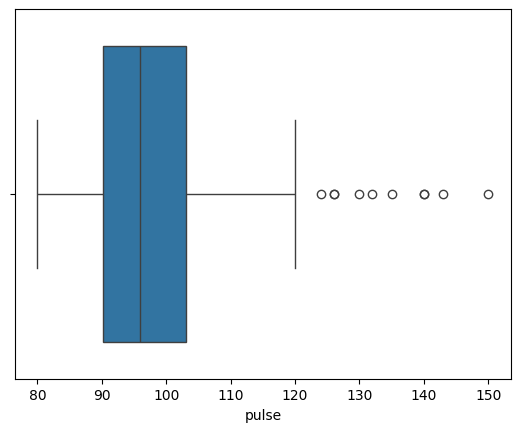

outliers:
     slno  id     diet  pulse    time     kind
70    70  24  low fat    132  15 min  running
76    76  26   no fat    126  15 min  running
77    77  26   no fat    143  30 min  running
79    79  27   no fat    126  15 min  running
80    80  27   no fat    140  30 min  running
82    82  28   no fat    124  15 min  running
83    83  28   no fat    140  30 min  running
85    85  29   no fat    135  15 min  running
86    86  29   no fat    130  30 min  running
89    89  30   no fat    150  30 min  running


In [12]:
sns.boxplot(x = df['pulse'])
plt.show()

Q1 = df['pulse'].quantile(0.25)
Q3 = df['pulse'].quantile(0.75)

IQR = Q3 - Q1

low = Q1 - 1.5*IQR
high = Q3 + 1.5*IQR

print("outliers:\n", df[(df['pulse'] < low) | (df['pulse'] > high)])

In [29]:
import pandas as pd
import numpy as np

df['time'] = df['time'].astype(str).str.extract('(\d+)').astype(float)
df['pulse'] = df['pulse'].astype(str).str.extract('(\d+)').astype(float)

print("NaN count:\n", df[['time','pulse']].isna().sum())

df_clean = df[['time','pulse']].dropna()

print("Remaining rows:", len(df_clean))

print("Manual:", np.corrcoef(df_clean['time'], df_clean['pulse'])[0,1])
print("Built-in:", df_clean['time'].corr(df_clean['pulse']))

NaN count:
 time     90
pulse     0
dtype: int64
Remaining rows: 0
Manual: nan
Built-in: nan


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_23490/2368703622.py:5: SyntaxWarning: invalid escape sequence '\d'
  df['time'] = df['time'].astype(str).str.extract('(\d+)').astype(float)
/tmp/ipykernel_23490/2368703622.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['pulse'] = df['pulse'].astype(str).str.extract('(\d+)').astype(float)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/

In [30]:
df.head()

,slno,id,diet,pulse,time,kind
0,0,1,low fat,85.0,NaN,rest
1,1,1,low fat,85.0,NaN,rest
2,2,1,low fat,88.0,NaN,rest
3,3,2,low fat,90.0,NaN,rest
4,4,2,low fat,92.0,NaN,rest


In [31]:
df['time'] = range(len(df))

In [32]:
import numpy as np

print("Manual:", np.corrcoef(df['time'], df['pulse'])[0,1])
print("Built-in:", df['time'].corr(df['pulse']))

Manual: 0.6884887256791001
Built-in: 0.6884887256791001


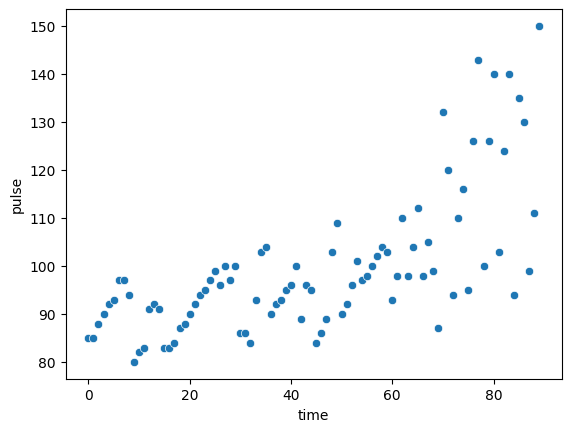

In [33]:
sns.scatterplot(x='time', y='pulse', data=df)
plt.show()

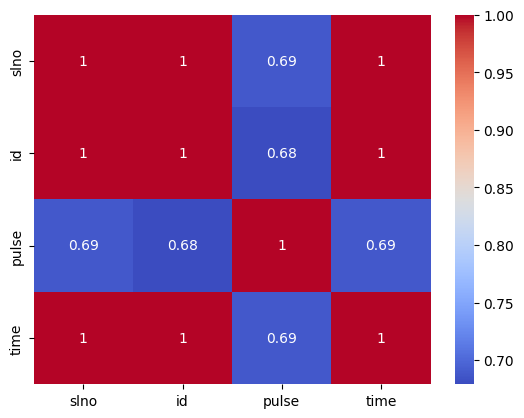

In [34]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

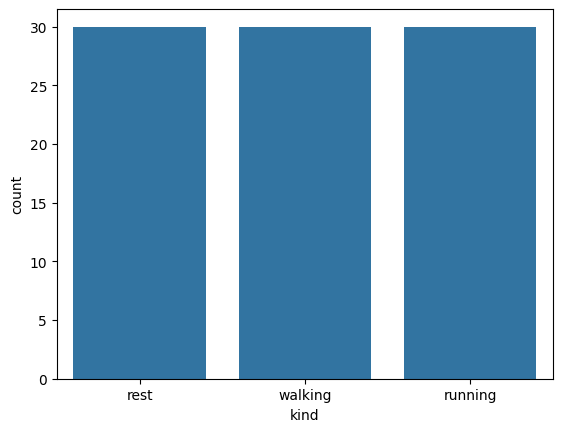

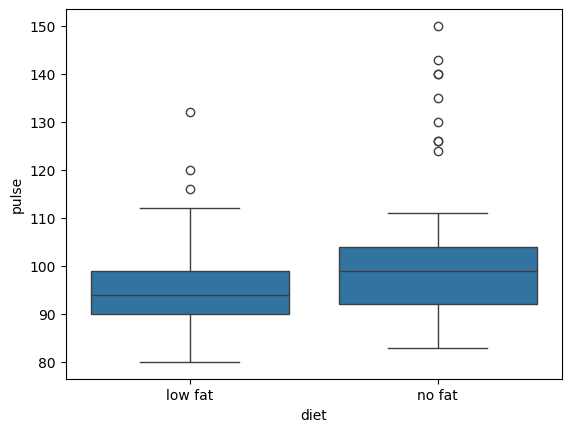

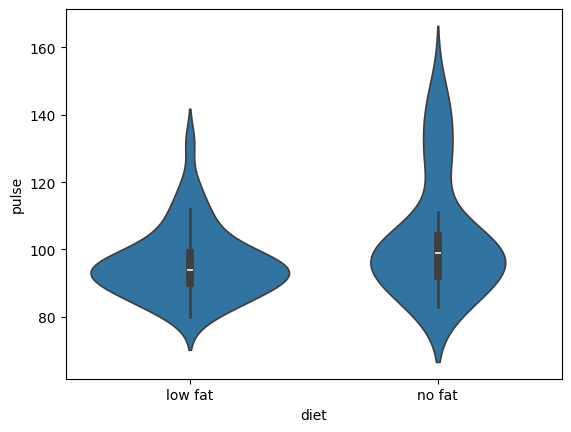

In [35]:
# count plot
sns.countplot(x='kind', data=df)
plt.show()

# box plot
sns.boxplot(x='diet', y='pulse', data=df)
plt.show()

# violin plot
sns.violinplot(x='diet', y='pulse', data=df)
plt.show()

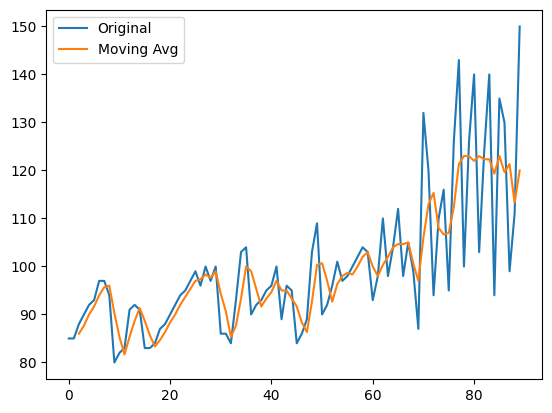

In [36]:
plt.plot(df['time'], df['pulse'], label='Original')

ma = df['pulse'].rolling(3).mean()
plt.plot(df['time'], ma, label='Moving Avg')

plt.legend()
plt.show()

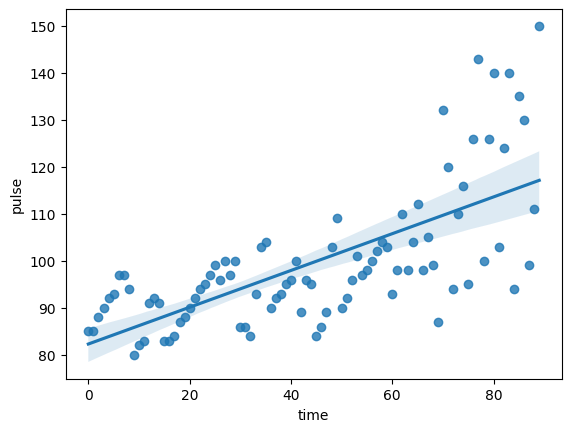

In [37]:
sns.regplot(x='time', y='pulse', data=df)
plt.show()

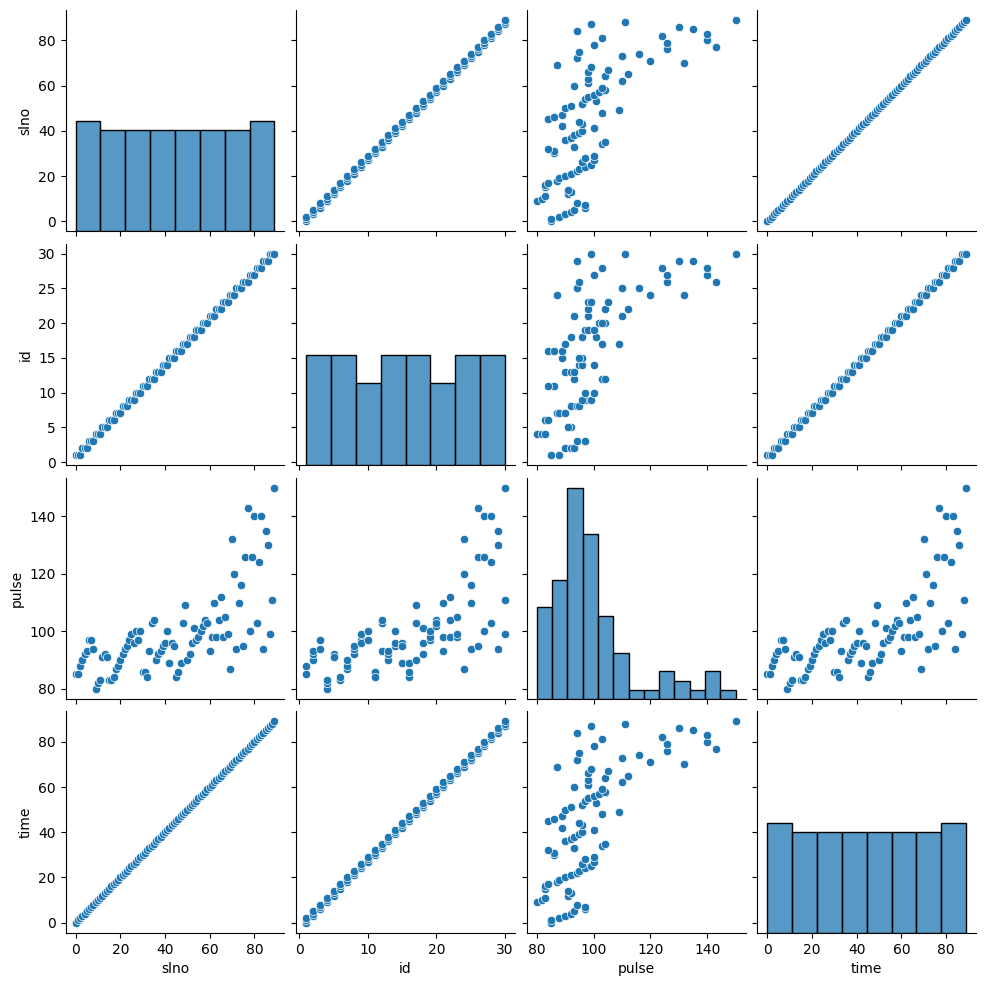

In [38]:
sns.pairplot(df)
plt.show()

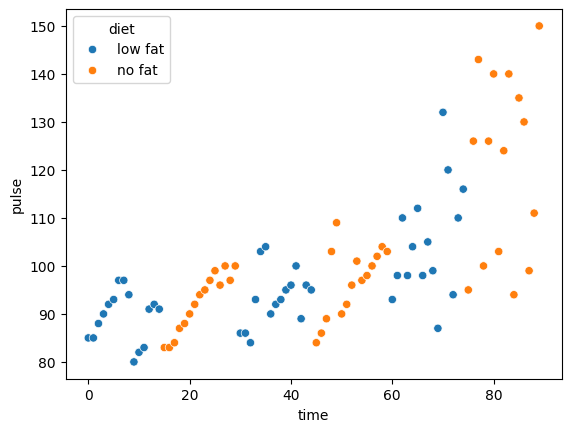

In [39]:
sns.scatterplot(x='time', y='pulse', hue='diet', data=df)
plt.show()